In this notebook, we'll calculate the level of agreement between elements of a class of digits. There are 10 classes of digits 0-9. Let $a$ be an element of class $A$ and $b$ be an element of class $B$. For current purposes, the level of agreement between $a$ and $b$ is given by

$$
    \frac{shit}{fuck}.
$$

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import morphology as morph
from scipy.signal import fftconvolve, correlate
import numpy.linalg as LA
from sklearn.datasets import fetch_openml

In [30]:
# Load MNIST data from https://www.openml.org/d/554
images, labels = fetch_openml('mnist_784', version=1, return_X_y=True)

In [64]:
''' Right now the images and labels are in separate arrays. 
    I'll put them into a single pandas DataFrame to make it
    easier to sort by label.
'''

images = pd.DataFrame(zip(images,labels), columns = ['Image','Class label'])
images

TypeError: only size-1 arrays can be converted to Python scalars

In [35]:
# Not really necessary, but I'll sort the images by class label.
images.sort_values(by = 'Class label', inplace = True)
images

,Image,Class label
34999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
26300,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
26298,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
26292,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
48670,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
...,...,...
44022,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
55126,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
55125,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
18166,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9


In [69]:
# By default, the 'Class label' column is not integer, so we'll convert it here.
images['Class label'] = images['Class label'].apply(int)
images

,Image,Class label
34999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
26300,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
26298,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
26292,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
48670,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
...,...,...
44022,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
55126,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
55125,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
18166,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9


In [79]:
# The images are also flattened, so we'll reshape them to (28,28)
images['Image'] = images['Image'].apply(lambda x: x.reshape((28,28)))
images

,Image,Class label
34999,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0
26300,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0
26298,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0
26292,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0
48670,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0
...,...,...
44022,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9
55126,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9
55125,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9
18166,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",9


In [80]:
def extract_image(frame, digit):
    """ This function takes in a dataset containing images. 
        The set is converted to a DataFrame, and the images
        corresponding to the given digit are extracted.
        
        An array containing images of the given digit is
        returned.
    """
        
    ims = frame[frame['Class label'] == digit]
    
    # Now ims only contains labels matching the digit, so we can drop the label column.
    ims.drop('Class label', axis = 1, inplace = True)
    
    return np.array(ims['Image'])

def display_lengths(data):
    """ Display the total length of each subset of digits. 
    
        Used for checking that the conversion worked as expected.
    """
    
    for i in range(10):
        print('{} examples of digit {}'.format(len(data[i]), i))
    print('{} examples in total\n'.format(sum(len(data[i]) for i in range(10))))
    return None

In [81]:
data = [extract_image(images, i) for i in range(10)]
display_lengths(data)

6903 examples of digit 0
7877 examples of digit 1
6990 examples of digit 2
7141 examples of digit 3
6824 examples of digit 4
6313 examples of digit 5
6876 examples of digit 6
7293 examples of digit 7
6825 examples of digit 8
6958 examples of digit 9
70000 examples in total



In [82]:
# Finally, save each digit separately

zero = data[0]
one = data[1]
two = data[2]
three = data[3]
four = data[4]
five = data[5]
six = data[6]
seven = data[7]
eight = data[8]
nine = data[9]

In [87]:
# Take N samples from each digit

N = 100

sample0 = zero[:N]
sample1 = one[:N]
sample2 = two[:N]
sample3 = three[:N]
sample4 = four[:N]
sample5 = five[:N]
sample6 = six[:N]
sample7 = seven[:N]
sample8 = eight[:N]
sample9 = nine[:N]

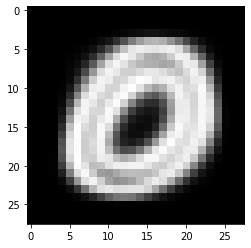

In [88]:
# Variance of the zero digits
plt.imshow(zero.var(), cmap = 'gray');

Now we'll calculate the pairwise agreement with a subset of 500 examples of zeros.

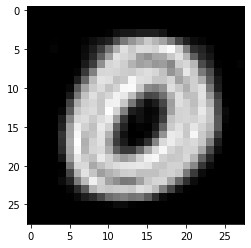

In [89]:
# I want to see if the variance of our sample is similar to that of the full set
plt.imshow(sample0.var(), cmap = 'gray');

In [90]:
# Calculate the agreement of elements of zero_sample with all other elements.
def calculate_agreement(sample):
    """ Calculate the level of agreement between every 
        element in sample and all other elements in sample.
        
        The level of agreement is
        ||A (star) B||/sqrt(||A(star)A||)sqrt(||B(star)B||)
    """
    
    correlations = [LA.norm(correlate(A,B,method='fft',mode='same'),ord='fro')/(np.sqrt(LA.norm(correlate(A,A,method='fft',mode='same'),ord='fro'))*np.sqrt(LA.norm(correlate(B,B,method='fft',mode='same'),ord='fro'))) for A in sample for B in sample]
    return correlations
    

In [91]:
corr = calculate_agreement(sample0)

In [93]:
agreement_chart = pd.DataFrame(np.array(corr).reshape(100,100))
agreement_chart

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,1.000000,0.935405,0.949377,0.920074,0.947271,0.990150,0.927422,0.926287,0.951758,0.944461,...,0.940006,0.952805,0.994869,0.949285,0.969458,0.957509,0.942031,0.995793,0.986260,0.931476
1,0.934414,1.000000,0.914785,0.908914,0.911875,0.941508,0.904030,0.899330,0.896794,0.908249,...,0.893928,0.911982,0.930192,0.915407,0.933601,0.913730,0.906392,0.924792,0.917457,0.898058
2,0.947742,0.916593,1.000000,0.952656,0.989709,0.949389,0.977231,0.979553,0.960990,0.965547,...,0.976191,0.988084,0.951073,0.989642,0.954215,0.973354,0.975724,0.946206,0.960596,0.953238
3,0.920282,0.909226,0.952924,1.000000,0.957168,0.918698,0.958850,0.923258,0.927153,0.961396,...,0.922594,0.945776,0.929245,0.971320,0.949582,0.954702,0.946043,0.922782,0.933906,0.964939
4,0.949025,0.913156,0.991779,0.960458,1.000000,0.942134,0.975859,0.961686,0.973626,0.986077,...,0.969582,0.989090,0.955770,0.995511,0.954971,0.987303,0.985126,0.947609,0.966003,0.964062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.960024,0.917011,0.975708,0.966185,0.990370,0.953775,0.977863,0.949397,0.982392,0.990095,...,0.963610,0.988887,0.969443,0.978408,0.962462,1.000000,0.980865,0.961830,0.982706,0.967842
96,0.944874,0.910097,0.977846,0.951218,0.986210,0.941822,0.967956,0.947516,0.979249,0.977424,...,0.957570,0.982382,0.951900,0.973570,0.948599,0.981192,1.000000,0.947434,0.964341,0.963351
97,0.995769,0.925326,0.946603,0.921322,0.943259,0.990280,0.922016,0.919389,0.951222,0.940876,...,0.932926,0.951684,0.992501,0.945606,0.964199,0.957845,0.942563,1.000000,0.988795,0.929477
98,0.985082,0.917127,0.959055,0.929289,0.960458,0.980695,0.935643,0.930426,0.974797,0.959283,...,0.952232,0.972077,0.990366,0.960110,0.969898,0.974599,0.958126,0.988177,1.000000,0.950310


I think that using correlations is causing some trouble with our norms in that we're getting higher than expected agreement. In the next few cells, I'll just use the vector product instead of cross-correlations.

In [94]:
agree = [LA.norm(A*B,np.inf)/(np.sqrt(LA.norm(A*A,np.inf))*np.sqrt(LA.norm(B*B,np.inf))) for A in sample0 for B in sample0]

In [95]:
agree_chart = pd.DataFrame(np.array(agree).reshape(100,100))
agree_chart

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,1.000000,0.737124,0.776043,0.525916,0.857818,0.851374,0.755711,0.683392,0.916544,0.819844,...,0.795554,0.851050,0.953320,0.815467,0.839546,0.722122,0.778783,0.976661,0.873533,0.775142
1,0.737124,1.000000,0.622465,0.820393,0.623726,0.673853,0.694103,0.646740,0.447759,0.606963,...,0.676643,0.636293,0.532880,0.665295,0.778898,0.610206,0.607681,0.630302,0.564332,0.793681
2,0.776043,0.622465,1.000000,0.769724,0.700278,0.662976,0.830852,0.698902,0.611855,0.708659,...,0.829993,0.838971,0.609112,0.854512,0.730977,0.765529,0.777565,0.778850,0.598052,0.783267
3,0.525916,0.820393,0.769724,1.000000,0.797046,0.339563,0.856576,0.426276,0.577383,0.737373,...,0.729625,0.730411,0.603725,0.791895,0.898378,0.582399,0.588776,0.476847,0.547550,0.879978
4,0.857818,0.623726,0.700278,0.797046,1.000000,0.706165,0.873814,0.809548,0.825913,0.792363,...,0.912569,0.949332,0.872060,0.680843,0.758263,0.762224,0.692448,0.849207,0.933883,0.807740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.722122,0.610206,0.765529,0.582399,0.762224,0.467858,0.540623,0.625140,0.726738,0.609239,...,0.762426,0.900341,0.582081,0.833709,0.776180,1.000000,0.838095,0.725879,0.654128,0.737328
96,0.778783,0.607681,0.777565,0.588776,0.692448,0.596961,0.554070,0.600794,0.728405,0.670031,...,0.826864,0.887119,0.686711,0.895111,0.807028,0.838095,1.000000,0.815770,0.653232,0.863945
97,0.976661,0.630302,0.778850,0.476847,0.849207,0.918804,0.679093,0.699547,0.768751,0.678129,...,0.713880,0.836599,0.961479,0.762223,0.656031,0.725879,0.815770,1.000000,0.864645,0.682252
98,0.873533,0.564332,0.598052,0.547550,0.933883,0.862305,0.747162,0.751141,0.829301,0.780379,...,0.785748,0.896657,0.908881,0.587547,0.635342,0.654128,0.653232,0.864645,1.000000,0.671002


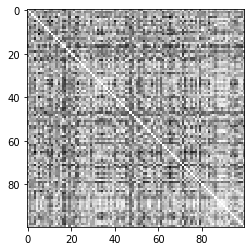

In [96]:
plt.imshow(agree_chart,cmap='gray');

From the chart above, it looks like sample elements 0 and 3 are very different. Let's take a look.

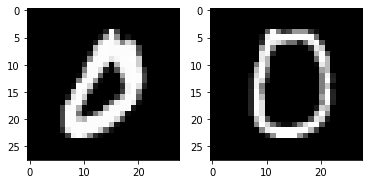

In [97]:
fig, ax = plt.subplots(1,2)

ax[0].imshow(sample0[0],cmap='gray')
ax[1].imshow(sample0[3],cmap='gray');

Ok, now let's take a much larger sample, 500 elements.

In [127]:
N = 10

sample0 = zero[:N]
sample1 = one[:N]
sample2 = two[:N]
sample3 = three[:N]
sample4 = four[:N]
sample5 = five[:N]
sample6 = six[:N]
sample7 = seven[:N]
sample8 = eight[:N]
sample9 = nine[:N]

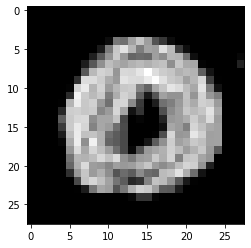

In [128]:
plt.imshow(sample0.var(), cmap='gray');

In [129]:
agree = [LA.norm(A*B,2)/(np.sqrt(LA.norm(A*A,2))*np.sqrt(LA.norm(B*B,2))) for A in sample0 for B in sample0]

In [135]:
agree_chart = pd.DataFrame(np.array(agree).reshape(N,N))
agree_chart

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.656503,0.680011,0.486905,0.614443,0.889763,0.542274,0.709024,0.700749,0.541086
1,0.656503,1.000000,0.653314,0.546296,0.524942,0.663419,0.548336,0.620353,0.490456,0.494519
2,0.680011,0.653314,1.000000,0.740443,0.830424,0.586961,0.720982,0.818497,0.695375,0.699328
3,0.486905,0.546296,0.740443,1.000000,0.750578,0.520646,0.862454,0.487822,0.544622,0.722313
4,0.614443,0.524942,0.830424,0.750578,1.000000,0.493201,0.800046,0.700870,0.781889,0.820682
5,0.889763,0.663419,0.586961,0.520646,0.493201,1.000000,0.432946,0.650152,0.536937,0.446452
6,0.542274,0.548336,0.720982,0.862454,0.800046,0.432946,1.000000,0.628259,0.636374,0.689430
7,0.709024,0.620353,0.818497,0.487822,0.700870,0.650152,0.628259,1.000000,0.652918,0.623240
8,0.700749,0.490456,0.695375,0.544622,0.781889,0.536937,0.636374,0.652918,1.000000,0.792982
9,0.541086,0.494519,0.699328,0.722313,0.820682,0.446452,0.689430,0.623240,0.792982,1.000000


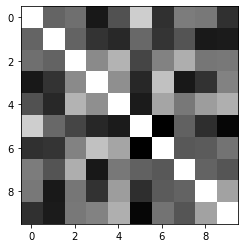

In [136]:
plt.imshow(agree_chart,cmap='gray');

Now I need to sort out the rows so that they fall off from 1 towards zero as you move away from the main diagonal.

In [148]:
agree_chart_sorted = agree_chart.unstack().sort_values(kind = 'quicksort')
agree_chart_sorted

6  5    0.432946
5  6    0.432946
9  5    0.446452
5  9    0.446452
0  3    0.486905
          ...   
5  5    1.000000
4  4    1.000000
8  8    1.000000
9  9    1.000000
6  6    1.000000
Length: 100, dtype: float64

In [149]:
agree_chart_sorted.unstack()

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.656503,0.680011,0.486905,0.614443,0.889763,0.542274,0.709024,0.700749,0.541086
1,0.656503,1.000000,0.653314,0.546296,0.524942,0.663419,0.548336,0.620353,0.490456,0.494519
2,0.680011,0.653314,1.000000,0.740443,0.830424,0.586961,0.720982,0.818497,0.695375,0.699328
3,0.486905,0.546296,0.740443,1.000000,0.750578,0.520646,0.862454,0.487822,0.544622,0.722313
4,0.614443,0.524942,0.830424,0.750578,1.000000,0.493201,0.800046,0.700870,0.781889,0.820682
5,0.889763,0.663419,0.586961,0.520646,0.493201,1.000000,0.432946,0.650152,0.536937,0.446452
6,0.542274,0.548336,0.720982,0.862454,0.800046,0.432946,1.000000,0.628259,0.636374,0.689430
7,0.709024,0.620353,0.818497,0.487822,0.700870,0.650152,0.628259,1.000000,0.652918,0.623240
8,0.700749,0.490456,0.695375,0.544622,0.781889,0.536937,0.636374,0.652918,1.000000,0.792982
9,0.541086,0.494519,0.699328,0.722313,0.820682,0.446452,0.689430,0.623240,0.792982,1.000000


In [139]:
agree_chart.loc[0].min()

0.4869047452144424

In [141]:
agree_chart.rank()

,0,1,2,3,4,5,6,7,8,9
0,10.0,8.0,3.0,1.0,3.0,9.0,2.0,8.0,7.0,3.0
1,5.0,10.0,2.0,5.0,2.0,8.0,3.0,2.0,1.0,2.0
2,6.0,7.0,10.0,7.0,9.0,6.0,7.0,9.0,6.0,6.0
3,1.0,4.0,7.0,10.0,5.0,4.0,9.0,1.0,3.0,7.0
4,4.0,3.0,9.0,8.0,10.0,3.0,8.0,7.0,8.0,9.0
5,9.0,9.0,1.0,3.0,1.0,10.0,1.0,5.0,2.0,1.0
6,3.0,5.0,6.0,9.0,7.0,1.0,10.0,4.0,4.0,5.0
7,8.0,6.0,8.0,2.0,4.0,7.0,4.0,10.0,5.0,4.0
8,7.0,1.0,4.0,4.0,6.0,5.0,5.0,6.0,10.0,8.0
9,2.0,2.0,5.0,6.0,8.0,2.0,6.0,3.0,9.0,10.0


In [150]:
# Experimenting with reordering the columns

cols = agree_chart.columns
cols

RangeIndex(start=0, stop=10, step=1)

In [152]:
cols = [0, 5, 7, 8, 2, 1, 4, 6, 9, 3]
agree_chart[cols].reindex(cols)

,0,5,7,8,2,1,4,6,9,3
0,1.000000,0.889763,0.709024,0.700749,0.680011,0.656503,0.614443,0.542274,0.541086,0.486905
5,0.889763,1.000000,0.650152,0.536937,0.586961,0.663419,0.493201,0.432946,0.446452,0.520646
7,0.709024,0.650152,1.000000,0.652918,0.818497,0.620353,0.700870,0.628259,0.623240,0.487822
8,0.700749,0.536937,0.652918,1.000000,0.695375,0.490456,0.781889,0.636374,0.792982,0.544622
2,0.680011,0.586961,0.818497,0.695375,1.000000,0.653314,0.830424,0.720982,0.699328,0.740443
1,0.656503,0.663419,0.620353,0.490456,0.653314,1.000000,0.524942,0.548336,0.494519,0.546296
4,0.614443,0.493201,0.700870,0.781889,0.830424,0.524942,1.000000,0.800046,0.820682,0.750578
6,0.542274,0.432946,0.628259,0.636374,0.720982,0.548336,0.800046,1.000000,0.689430,0.862454
9,0.541086,0.446452,0.623240,0.792982,0.699328,0.494519,0.820682,0.689430,1.000000,0.722313
3,0.486905,0.520646,0.487822,0.544622,0.740443,0.546296,0.750578,0.862454,0.722313,1.000000


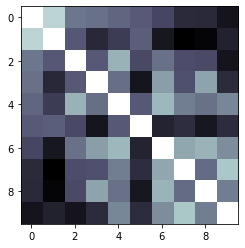

In [153]:
plt.imshow(agree_chart[cols].reindex(cols), cmap = 'bone');

In [156]:
# We need the sorted correlation matrix


ValueError: Shape of passed values is (10, 1), indices imply (10, 10)

In [159]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn import datasets
from fastcluster import linkage

import matplotlib.pyplot as plt
%matplotlib inline

In [160]:
iris = datasets.load_iris()
iris.data.shape

(150, 4)

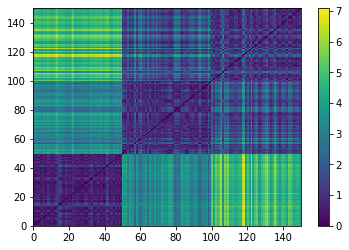

In [161]:
dist_mat = squareform(pdist(iris.data))

N = len(iris.data)
plt.pcolormesh(dist_mat)
plt.colorbar()
plt.xlim([0,N])
plt.ylim([0,N])
plt.show()

In [162]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

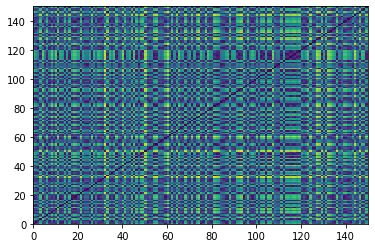

In [163]:
X = iris.data[np.random.permutation(N),:]

dist_mat = squareform(pdist(X))

plt.pcolormesh(dist_mat)
plt.xlim([0,N])
plt.ylim([0,N])
plt.show()


In [164]:
def seriation(Z,N,cur_index):
    '''
        input:
            - Z is a hierarchical tree (dendrogram)
            - N is the number of points given to the clustering process
            - cur_index is the position in the tree for the recursive traversal
        output:
            - order implied by the hierarchical tree Z
            
        seriation computes the order implied by a hierarchical tree (dendrogram)
    '''
    if cur_index < N:
        return [cur_index]
    else:
        left = int(Z[cur_index-N,0])
        right = int(Z[cur_index-N,1])
        return (seriation(Z,N,left) + seriation(Z,N,right))
    
def compute_serial_matrix(dist_mat,method="ward"):
    '''
        input:
            - dist_mat is a distance matrix
            - method = ["ward","single","average","complete"]
        output:
            - seriated_dist is the input dist_mat,
              but with re-ordered rows and columns
              according to the seriation, i.e. the
              order implied by the hierarchical tree
            - res_order is the order implied by
              the hierarhical tree
            - res_linkage is the hierarhical tree (dendrogram)
        
        compute_serial_matrix transforms a distance matrix into 
        a sorted distance matrix according to the order implied 
        by the hierarchical tree (dendrogram)
    '''
    N = len(dist_mat)
    flat_dist_mat = squareform(dist_mat)
    res_linkage = linkage(flat_dist_mat, method=method,preserve_input=True)
    res_order = seriation(res_linkage, N, N + N-2)
    seriated_dist = np.zeros((N,N))
    a,b = np.triu_indices(N,k=1)
    seriated_dist[a,b] = dist_mat[ [res_order[i] for i in a], [res_order[j] for j in b]]
    seriated_dist[b,a] = seriated_dist[a,b]
    
    return seriated_dist, res_order, res_linkage

Method:	 complete


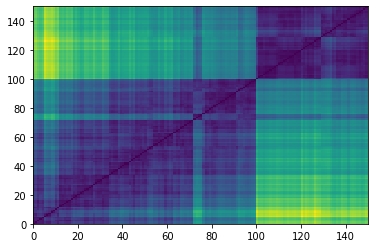

In [167]:
method = 'complete'

print("Method:\t",method)
    
ordered_dist_mat, res_order, res_linkage = compute_serial_matrix(dist_mat,method)

plt.pcolormesh(ordered_dist_mat)
plt.xlim([0,N])
plt.ylim([0,N])
plt.show()

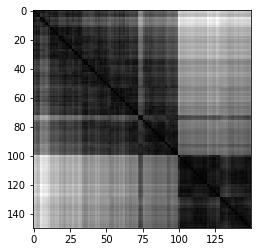

In [168]:
plt.imshow(ordered_dist_mat, cmap = 'gray');

Method:	 ward


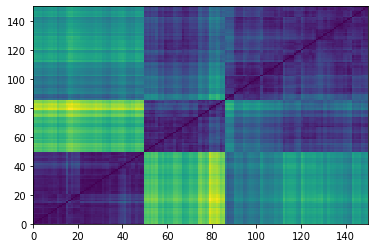

Method:	 single


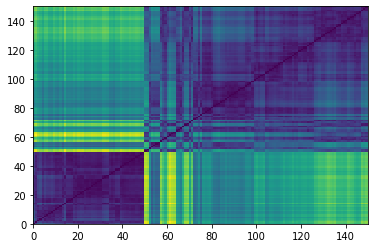

Method:	 average


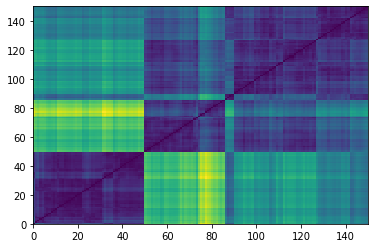

Method:	 complete


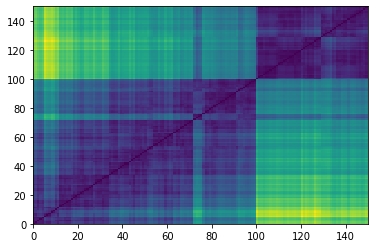

In [169]:
methods = ["ward","single","average","complete"]
for method in methods:
    print("Method:\t",method)
    
    ordered_dist_mat, res_order, res_linkage = compute_serial_matrix(dist_mat,method)
    
    plt.pcolormesh(ordered_dist_mat)
    plt.xlim([0,N])
    plt.ylim([0,N])
    plt.show()